### Classification

##### Logistic regression.

Difference between logistic and linear regression.
In linear regression, we use straight line.
In logistic regression, we use sigmoid function but the formula is still the same. 
y = mx+c
y = b0+b1x1+b2x2+ .... +bnxn

Only used for binary classification.

disease 40000 data  
25000 -> healthy, 5000 -> unhealthy
80% -> feature -> 40% healthy, 40% unhealthy
20% -> target -> 10% healthy, 10% unhealthy

data should be distributed equally.

stratify for Target

Logistic regression parameters
--------------------------------------
solver -> liblinear, lbfgs(default), saga

liblinear -> if our data is small sized (around 10 lakhs data)  
- Liblinear -> if our dataset is small sized   
- lbfgs(Limited-Memory Broyden-Fletcher-Goldfarb-Shanno) -> if our data is medium or large sized (10 lakhs +)
- saga -> if our data is large sized (>20 lakhs)

class_weight -> None(default), Balanced
random_state -> 42

### Metrics
- Classification Report
    Accuracy: overall percentage of correct predictions

  Recall(completeness): out of all actual events, how many did the model correctly catch

  Precision: when the model predicts an event, how often is it correct?

  F1-score:  A single score balancing both Precision and Recall OR average percentage of precision and recall

  support: total number of healthy and unhealthy data. healthy and unhealthy data are just examples since our dataset is about health
  
- Confusion Matrix (True Positive, True Negative, False Positive, False Negative)
  X -> Predicted Data
  Y -> Actual Data



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
df = pd.read_csv("Cardiovascular_Disease.csv")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [23]:
data = df[df.duplicated()]
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [24]:
df['age'] = df['age']//365

<Axes: xlabel='age', ylabel='Count'>

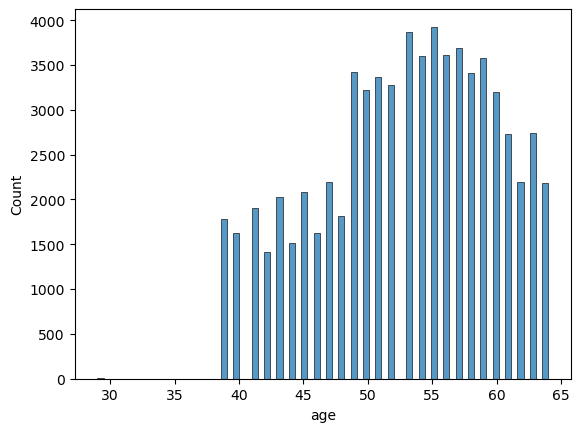

In [25]:
sns.histplot(df['age'])

<Axes: ylabel='age'>

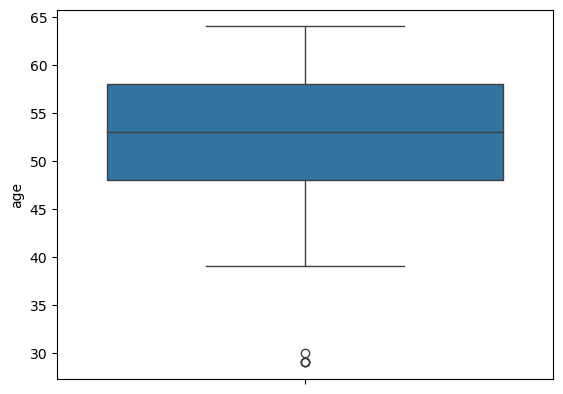

In [26]:
sns.boxplot(df['age'])

<Axes: ylabel='height'>

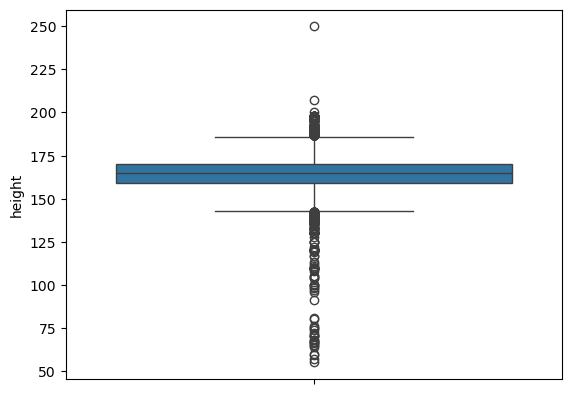

In [27]:
sns.boxplot(df['height'])

<Axes: >

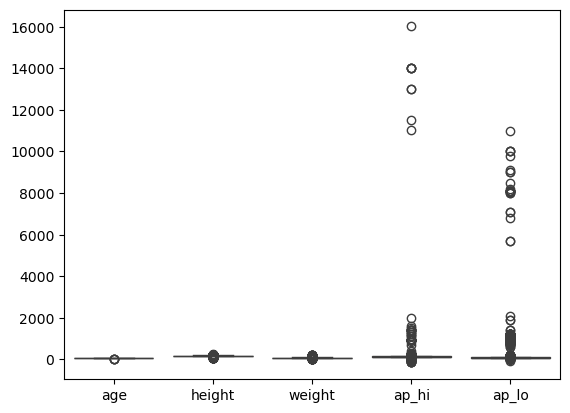

In [32]:
sns.boxplot(df[['age','height','weight','ap_hi','ap_lo']])

In [30]:
df['height'].max

<bound method Series.max of 0        168
1        156
2        165
3        169
4        156
        ... 
69995    168
69996    158
69997    183
69998    163
69999    170
Name: height, Length: 70000, dtype: int64>

In [31]:
data = df[(df['height'].between(150,200)) & (df['weight'].between(45,120)) & (df['ap_hi'].between(100,120)) & (df['ap_lo'].between(50,90))]
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
8,13,48,1,158,71.0,110,70,1,1,0,0,1,0
9,14,54,1,164,68.0,110,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69988,99981,60,1,160,59.0,110,70,1,1,0,0,1,0
69989,99985,57,1,157,83.0,120,70,1,1,0,0,1,1
69990,99986,41,1,168,72.0,110,70,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0


In [35]:
data = data.drop(columns = 'id')

<Axes: >

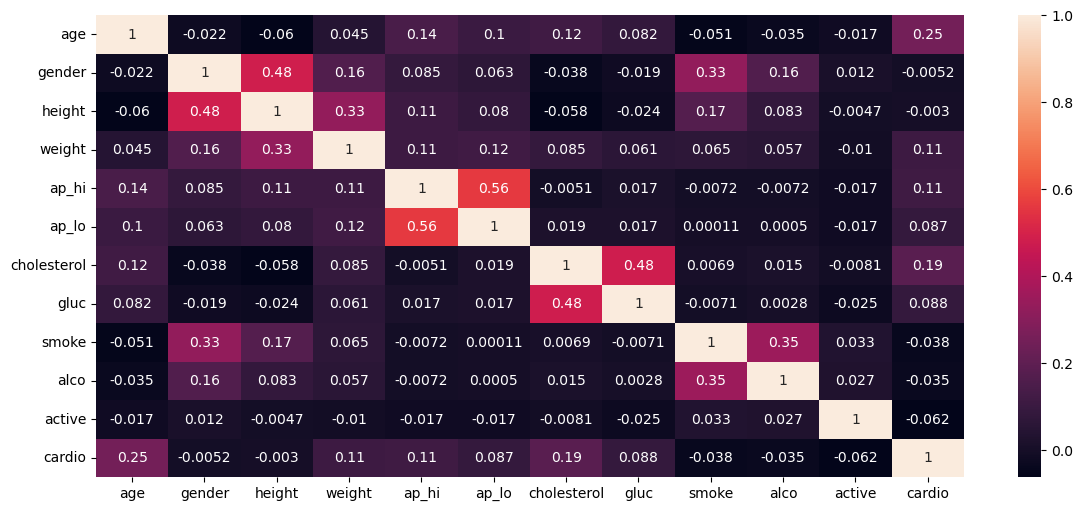

In [40]:
cor = data.corr()
plt.figure(figsize=(14,6))
sns.heatmap(cor,annot=True)

In [41]:
data.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [42]:
feature = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [43]:
X = data[feature]
Y = data[target]

In [44]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y, test_size=0.2, random_state = 42, stratify = Y
)

In [45]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [46]:
X_test_scale

array([[-1.72360347e+00,  1.37866917e+00, -1.39967241e-01, ...,
        -2.97154981e-01, -2.22024346e-01,  4.94314691e-01],
       [ 4.77224130e-01, -7.25337174e-01,  5.54229692e-01, ...,
        -2.97154981e-01, -2.22024346e-01,  4.94314691e-01],
       [-1.09663231e-01, -7.25337174e-01, -1.12785486e-03, ...,
        -2.97154981e-01, -2.22024346e-01,  4.94314691e-01],
       ...,
       [ 1.79772069e+00, -7.25337174e-01, -2.78806628e-01, ...,
        -2.97154981e-01, -2.22024346e-01, -2.02300279e+00],
       [-6.96550592e-01, -7.25337174e-01, -1.38952172e+00, ...,
        -2.97154981e-01, -2.22024346e-01, -2.02300279e+00],
       [ 9.17389650e-01, -7.25337174e-01,  2.76550918e-01, ...,
        -2.97154981e-01, -2.22024346e-01,  4.94314691e-01]],
      shape=(7663, 11))

In [49]:
model  = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

In [50]:
model.fit(X_train_scale,Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `

In [51]:
Y_pred = model.predict(X_test_scale)

## classification report

In [54]:
cr = classification_report(Y_test,Y_pred)
cm = confusion_matrix(Y_test,Y_pred)

In [55]:
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.78      0.63      0.70      5211
           1       0.45      0.63      0.52      2452

    accuracy                           0.63      7663
   macro avg       0.62      0.63      0.61      7663
weighted avg       0.68      0.63      0.64      7663

[[3291 1920]
 [ 902 1550]]
